In [1]:
#0. 最初要改变的变量
Topology_Version = 'gridx'
P=18
N=36

In [12]:
# ====================== 环境准备 ======================
# 1) 设定环境变量（必须在导入 matplotlib 之前执行）
import os




os.environ['QT_API'] = 'pyqt5'        # 指定使用 PyQt5 作为 Qt 绑定
os.environ['MPLBACKEND'] = 'QtAgg'    # 指定 Matplotlib 后端为 QtAgg（更推荐，替代 TkAgg）

# 2) 启动 Qt 事件循环（控制台模式下，让 Qt 窗口能实时响应）
%gui qt5

# 3) 检查 matplotlib backend
import matplotlib as mpl
mpl.rcParams.update({
    # 这里按系统常见字体给一串候选，存在则自动生效
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "SimSun",
                        "Noto Sans CJK SC", "Source Han Sans SC",
                        "Arial Unicode MS", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.unicode_minus": False,   # 负号用正常字符，避免被当作缺字形
})

print("backend (before pyplot):", mpl.get_backend())
# 如果不是 QtAgg，强制改为 QtAgg（注意：必须在导入 pyplot 前设置）
mpl.rcParams['backend'] = 'QtAgg'

# 4) 现在再导入 pyplot
import matplotlib.pyplot as plt
print("backend (after pyplot):", mpl.get_backend())
from config import DATA_DIR,INPUT_DIR
from typing import Dict, Any




backend (before pyplot): QtAgg
backend (after pyplot): QtAgg


In [2]:
from pathlib import Path
from src.viz.pyqt_main2 import SatelliteViewer
DATA_DIR = Path(r"D:\paper3")
BASEDIR =  DATA_DIR / "data"


Topology_DIR = 'topology_design'
Topology_Version = 'gridx'
TOPO_CFG_PATH=BASEDIR / Topology_DIR / Topology_Version/"config" / "motif.json"

xml_file = BASEDIR / 'satellitesposition' / "station_visible_satellites_20250106.xml"

# 数据处理
这一章节，我们要开始数据后处理，就是上面数据导出后，我们需要进行同轨异轨的一个分析验证


In [3]:
from pathlib import Path
import re
import pandas as pd


def read_pair_csv(
    csv_path,
    *,
    time_col="time",
    station_a_col="station_a",
    station_b_col="station_b",
    path_col="path",
    ensure_int=True,
):
    """
    读取一份 station 对的最短路径 CSV。

    支持两种情况：
    1) CSV 本身包含 station_a / station_b 列
    2) CSV 没有这两列时，从文件名中提取（如 region1--station12-region2--station19.csv）
    """
    path = Path(csv_path)
    df = pd.read_csv(path)

    # 缺列校验
    if time_col not in df.columns:
        raise ValueError(f"CSV 缺少列: {time_col} -> {path}")

    # 文件名兜底解析 station 对
    if station_a_col not in df.columns or station_b_col not in df.columns:
        m = re.match(r".*station(\d+)-[^-]*-station(\d+)", path.stem)
        if not m:
            raise ValueError(
                f"CSV 缺少 {station_a_col}/{station_b_col}，且文件名无法解析: {path.name}"
            )
        df[station_a_col] = int(m.group(1))
        df[station_b_col] = int(m.group(2))

    # 可选字段保证存在
    if path_col not in df.columns:
        df[path_col] = ""

    if ensure_int:
        df[time_col] = pd.to_numeric(df[time_col], errors="coerce").astype("Int64")
        df[station_a_col] = pd.to_numeric(df[station_a_col], errors="coerce").astype("Int64")
        df[station_b_col] = pd.to_numeric(df[station_b_col], errors="coerce").astype("Int64")

    # 简单标准列
    return (
        df
        .loc[:, [time_col, station_a_col, station_b_col, path_col] + [
            c for c in df.columns
            if c not in {time_col, station_a_col, station_b_col, path_col}
        ]]
        .copy()
    )


In [4]:


DATA_DIR = Path(r"D:\paper3")
BASEDIR =  DATA_DIR / "data"

Topology_DIR = 'topology_design'

In [5]:
FIGURE_DIR = BASEDIR / Topology_DIR / Topology_Version/"path"

data_DIR = Path(FIGURE_DIR) / "region_pairs_0_86164"   # 你导出的原始 csv 目录


In [6]:

# data_DIR = Path(FIGURE_DIR) / "region1_to_region2_0_100"   # 你导出的原始 csv 目录

df = read_pair_csv(data_DIR / "region1--station0-region2--station19.csv")

In [6]:
df

,time,station_a,station_b,path,best_s,best_d,path_indexed
0,0,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
1,1,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
2,2,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
3,3,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
4,4,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
...,...,...,...,...,...,...,...
96,96,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
97,97,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
98,98,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
99,99,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."


In [7]:
dfpath = df["path"]

In [8]:
# ========== 路径 → intra/inter 链路分类 ==========
# 星座参数
# P = 18
# N = 36

import src.model.get_intra_inter_link as get_intra_inter_link
# def parse_path_links(path_str, N=36):
#     """
#     输入: '86->85->120->119->...'
#     输出: (intra_links, inter_links)
#         intra_links: [(86,85), ...]   同轨链路（orbit 相同）
#         inter_links: [(85,120), ...]  异轨链路（orbit 不同）
#     """
#     if not path_str or path_str == "":
#         return [], []
#
#     nodes = [int(x) for x in path_str.split("->")]
#     intra_links = []
#     inter_links = []
#
#     for i in range(len(nodes) - 1):
#         src, dst = nodes[i], nodes[i + 1]
#         src_orbit = src // N
#         dst_orbit = dst // N
#
#         if src_orbit == dst_orbit:
#             intra_links.append((src, dst))
#         else:
#             inter_links.append((src, dst))
#
#     return intra_links, inter_links


# ========== 对 dfpath 整列批量处理 ==========
# 假设 dfpath 是 DataFrame 的 "path" 列，即 df["path"]

all_intra = []
all_inter = []

for idx, path_str in enumerate(df["path"]):
    intra, inter = get_intra_inter_link.parse_path_links(path_str, N=N)
    all_intra.append(intra)
    all_inter.append(inter)

# 写回 DataFrame
df["intra_links"] = all_intra    # 每行是 [(src,dst), ...] 的 list
df["inter_links"] = all_inter

# 同时统计跳数
df["intra_hops"] = df["intra_links"].apply(len)
df["inter_hops"] = df["inter_links"].apply(len)
df["total_hops"] = df["intra_hops"] + df["inter_hops"]


In [12]:
df["intra_hops"]


0      6
1      6
2      6
3      6
4      6
      ..
96     6
97     6
98     6
99     6
100    6
Name: intra_hops, Length: 101, dtype: int64

In [9]:
def plot_intra_inter_hops_over_time(
    df,
    *,
    time_col="time",
    intra_col="intra_hops",
    inter_col="inter_hops",
    figsize=(10, 4),
    title="Intra-orbit vs Inter-orbit hops over time",
    show=True,
    save=None,
    save_dir="figs",
    basename="intra_inter_hops",
    formats=("png", "pdf"),
    dpi=300,
    return_handles=True,
):
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    base_rc = {
        "font.family": "Times New Roman",
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.2,
    }

    plt.ion()
    with mpl.rc_context(base_rc):
        fig, ax = plt.subplots(figsize=figsize)

        t = df[time_col]

        ax.plot(t, df[intra_col], marker='o', markersize=3,
                linewidth=1.5, color='#2196F3', label='Intra-orbit hops')
        ax.plot(t, df[inter_col], marker='s', markersize=3,
                linewidth=1.5, color='#F44336', label='Inter-orbit hops')
        ax.plot(t, df[intra_col] + df[inter_col], marker='^', markersize=3,
                linewidth=1.2, color='#888888', linestyle='--', label='Total hops')

        ax.set_xlabel("Time Step")
        ax.set_ylabel("Hops")
        ax.set_title(title)
        ax.legend(framealpha=0.9)
        ax.grid(alpha=0.3, linestyle="--")
        plt.tight_layout()

        if show:
            plt.show(block=False)
            try:
                plt.pause(0.01)
            except Exception:
                pass

    if save:
        from pathlib import Path
        targets = []
        if save is True:
            outdir = Path(save_dir); outdir.mkdir(parents=True, exist_ok=True)
            for ext in formats:
                targets.append(outdir / f"{basename}.{ext.lstrip('.')}")
        else:
            targets = [save] if isinstance(save, (str, Path)) else list(save)
        for p in targets:
            p = Path(p)
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=dpi, bbox_inches="tight")

    return (fig, ax, df) if return_handles else None


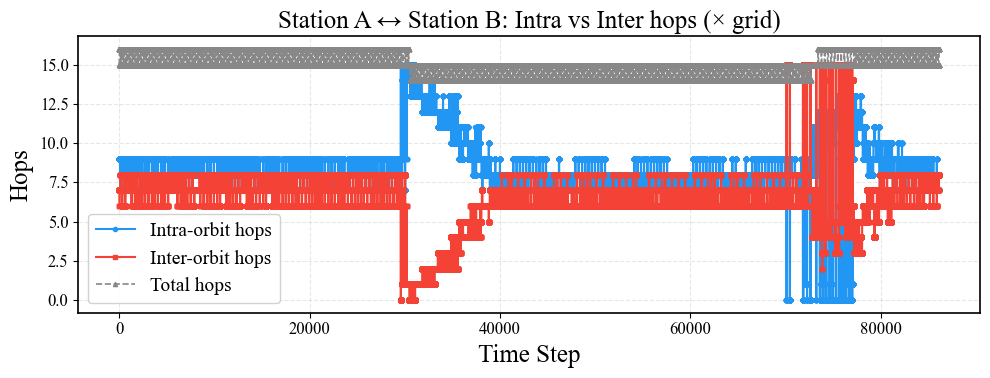

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Station A ↔ Station B: Intra vs Inter hops (× grid)'}, xlabel='Time Step', ylabel='Hops'>,
         time  station_a  station_b  \
 0          0          0         19   
 1          1          0         19   
 2          2          0         19   
 3          3          0         19   
 4          4          0         19   
 ...      ...        ...        ...   
 86160  86160          0         19   
 86161  86161          0         19   
 86162  86162          0         19   
 86163  86163          0         19   
 86164  86164          0         19   
 
                                                     path  best_s  best_d  \
 0      213->214->179->144->109->110->75->76->77->78->...     213     192   
 1      213->214->179->144->109->110->75->76->77->78->...     213     192   
 2      213->214->179->144->109->110->75->76->77->78->...     213     192   
 3      248->213->214->179->144->109->110->75->76->77-...     248   

In [10]:
plot_intra_inter_hops_over_time(
    df,
    title="Station A ↔ Station B: Intra vs Inter hops (× grid)",
)


In [11]:
def plot_route_reliability_over_time(
    df,
    *,
    p_intra=0.999,
    p_inter=0.99,
    intra_col="intra_hops",
    inter_col="inter_hops",
    time_col="time",
    figsize=(10, 4),
    title=None,
    show=True,
    save=None,
    save_dir="figs",
    basename="route_reliability",
    formats=("png", "pdf"),
    dpi=300,
    return_handles=True,
):
    """
    路由端到端稳定概率 = p_intra^(intra_hops) × p_inter^(inter_hops)
    """
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np

    reliability = (p_intra ** df[intra_col]) * (p_inter ** df[inter_col])

    # 写回 DataFrame 方便后续使用
    col_name = f"reliability_pi{p_intra}_pe{p_inter}"
    df[col_name] = reliability

    base_rc = {
        "font.family": "Times New Roman",
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.2,
    }

    plt.ion()
    with mpl.rc_context(base_rc):
        fig, ax = plt.subplots(figsize=figsize)

        ax.plot(df[time_col], reliability * 100,
                marker='o', markersize=3, linewidth=1.5, color='#4CAF50')

        ax.set_xlabel("Time Step")
        ax.set_ylabel("Route Reliability (%)")
        ax.set_ylim(bottom=max(0, (reliability.min() * 100) - 2),
                     top=min(100, (reliability.max() * 100) + 1))

        if title is None:
            title = (f"End-to-End Route Reliability "
                     f"($p_{{intra}}$={p_intra}, $p_{{inter}}$={p_inter})")
        ax.set_title(title)
        ax.grid(alpha=0.3, linestyle="--")
        plt.tight_layout()

        if show:
            plt.show(block=False)
            try:
                plt.pause(0.01)
            except Exception:
                pass

    if save:
        from pathlib import Path
        targets = []
        if save is True:
            outdir = Path(save_dir); outdir.mkdir(parents=True, exist_ok=True)
            for ext in formats:
                targets.append(outdir / f"{basename}.{ext.lstrip('.')}")
        else:
            targets = [save] if isinstance(save, (str, Path)) else list(save)
        for p in targets:
            p = Path(p)
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=dpi, bbox_inches="tight")

    return (fig, ax, df) if return_handles else None


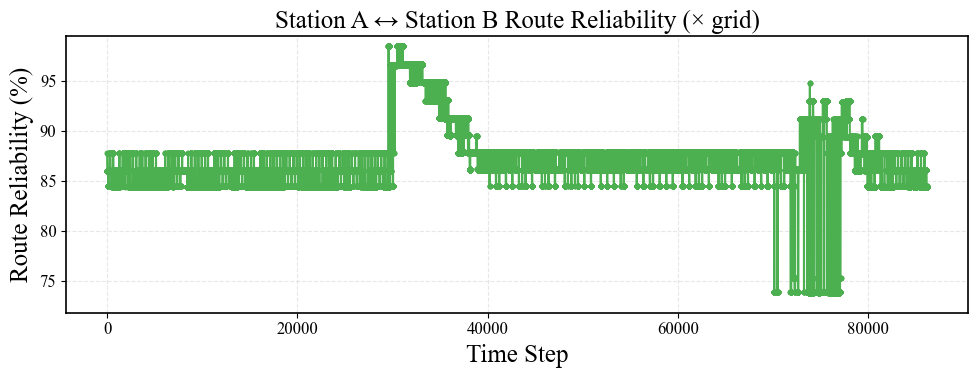

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Station A ↔ Station B Route Reliability (× grid)'}, xlabel='Time Step', ylabel='Route Reliability (%)'>,
         time  station_a  station_b  \
 0          0          0         19   
 1          1          0         19   
 2          2          0         19   
 3          3          0         19   
 4          4          0         19   
 ...      ...        ...        ...   
 86160  86160          0         19   
 86161  86161          0         19   
 86162  86162          0         19   
 86163  86163          0         19   
 86164  86164          0         19   
 
                                                     path  best_s  best_d  \
 0      213->214->179->144->109->110->75->76->77->78->...     213     192   
 1      213->214->179->144->109->110->75->76->77->78->...     213     192   
 2      213->214->179->144->109->110->75->76->77->78->...     213     192   
 3      248->213->214->179->144->109->110->75->76->77-

In [12]:
plot_route_reliability_over_time(
    df,
    p_intra=0.999,
    p_inter=0.98,
    title="Station A ↔ Station B Route Reliability (× grid)",
)


In [ ]:
# ## 读取motif
# ## 这一段仅仅是为了演示读取config文件而已
# import src.model.basiclink as basiclink
# S6=series_by_station[2]
# S8=series_by_station[20]
# from draw.basic_functio.topology_config import TopologyRecorder
# from draw.basic_functio.topology_config import load_config
# import src.io.operate_group_data as operate_group_data
# cfg = load_config(BASEDIR / Topology_DIR / Topology_Version/"config" / "motif.json")
# # 重建 recorder，把 motif 列表灌进去
# rec = TopologyRecorder(cfg.P, cfg.N)
# rec._motifs = cfg.motifs
#
# inter_adj = rec.render_adj_at(t=0, eval_env={"start_ts": 0, "end_ts": 1})
#
#
# # 如果你已经是 raw 坐标设计，直接用 inter_once
# raw_inter_once = inter_adj
#
# # 3) 你现有的双向化函数，复用
# raw_inter_once = basiclink.make_edges_bidirectional(raw_inter_once)
#
# # 4) 静态总图 = intra ring + static inter
# base_neighbors = {
#     i * N + j: (i * N + ((j + 1) % N), i * N + ((j - 1) % N))
#     for i in range(P) for j in range(N)
# }
# static_edges = {node: {r, l} for node, (r, l) in base_neighbors.items()}
# for src, dsts in raw_inter_once.items():
#     static_edges.setdefault(src, set()).update(dsts)
#
#
# # 5) 按现有 API 组装 step->adj（每个 step 共用同一张图）
# all_edges = {step: static_edges for step in range(RAW_START, RAW_END)}
#
#
#
# # 可选：做一个仅S6/S8的viewer配置，让图例更清楚
# PAIR_CFG = ViewerConfig(
#     name="S6_S8_VERIFY",
#     N=G60_CONFIG.N,
#     P=G60_CONFIG.P,
#     station_groups={
#         0: {"name": "S6", "stations": [5]},
#         1: {"name": "S8", "stations": [7]},
#     },
#     group_colors=["#ff4d4f", "#2f54eb"],
# )
# df_s6_s8 = df
# # =========================
# # 4) 把最短路叠加到 viewer（蓝色路径）
# # =========================
# path_by_step = {}
# for row in df_s6_s8.itertuples(index=False):
#     p = getattr(row, "path", "")
#     if isinstance(p, str) and p.strip():
#         path_by_step[int(row.time)] = [int(x) for x in p.split("->")]
#
#
# sub_edges = {t: all_edges.get(t, {}) for t in range(RAW_START, RAW_END + 1)}
#
#
# group_data_s6_s8 = operate_group_data.build_stationpair_group_data(S6, S8, RAW_START, RAW_END)
# viewer = SatelliteViewer(group_data_s6_s8, PAIR_CFG)
# viewer.setWindowTitle("verify S6-S8 shortest path (100s)")
# viewer.resize(1400, 800)
# viewer.edges_by_step = sub_edges
# viewer.set_paths(path_by_step)   # 叠加每步最短路（蓝线）
#
# viewer.show()
#
# # 2) 确保 viewer 有全局引用，避免 GC 回收导致崩溃
# if not hasattr(sys.modules[__name__], "_viewer_list"):
#     _viewer_list = []
#
#
# _viewer_list.append(viewer)


In [21]:
# # 你的 TOTAL_END 在外层循环是“右开”，所以这里用 TOTAL_END-1 做闭区间
# # =========================
# # A) 循环外：准备 region station 列表 + 一次性解析 series
# # =========================
# import src.model.plot_2city_shortest_path as plot_2city_shortest_path
# from src.config.viewer_config import G60_CONFIG
# from src.io import read_snap_xml
# RAW_START = 0
# RAW_END = 86400
# # 区域定义（从 G60_CONFIG.station_groups 读取）
# all_regions = {}
# for gid, info in G60_CONFIG.station_groups.items():
#     all_regions[gid] = info["stations"]
#
# # 收集所有 station id
# all_station_ids = sorted(set(
#     sid for stations in all_regions.values() for sid in stations
# ))
#
# # 如果你要严格用 1..11 和 12..21，请改成：
# # region_a_stations = list(range(1, 12))
# # region_b_stations = list(range(12, 22))
#
#
#
# series_list = read_snap_xml.parse_station_timeseries(
#     xml_file, all_station_ids, RAW_START, RAW_END - 1
# )
# series_by_station = {sid: ts for sid, ts in zip(all_station_ids, series_list)}


In [7]:
import draw.read_snap_xml  as read_snap_xml
from src.config.viewer_config import ViewerConfig, G60_CONFIG


# df 就是你前面已经读好的 DataFrame
df_s6_s8 = df

# 1) 从 df 里拿当前 station pair
station_a = int(df_s6_s8["station_a"].iloc[0])
station_b = int(df_s6_s8["station_b"].iloc[0])

# 2) 时间窗直接用 df 的范围，不要整天都画
WIN_START = int(df_s6_s8["time"].min())
WIN_END = int(df_s6_s8["time"].max())



In [8]:
# 区域定义（从 G60_CONFIG.station_groups 读取）
all_regions = {}
for gid, info in G60_CONFIG.station_groups.items():
    all_regions[gid] = info["stations"]

# 收集所有 station id
all_station_ids = sorted(set(
    sid for stations in all_regions.values() for sid in stations
))

# 如果你要严格用 1..11 和 12..21，请改成：
# region_a_stations = list(range(1, 12))
# region_b_stations = list(range(12, 22))



series_list = read_snap_xml.parse_station_timeseries(
    xml_file, all_station_ids, WIN_START, WIN_END - 1
)
series_by_station = {sid: ts for sid, ts in zip(all_station_ids, series_list)}


In [9]:
import src.model.basiclink as basiclink
from draw.basic_functio.topology_config import TopologyRecorder, load_config

cfg = load_config(BASEDIR / Topology_DIR / Topology_Version / "config" / "motif.json")
N = cfg.N
P = cfg.P

rec = TopologyRecorder(cfg.P, cfg.N)
rec._motifs = cfg.motifs

# 静态拓扑，只 render 一次
inter_adj = rec.render_adj_at(
    t=WIN_START,
    eval_env={"start_ts": WIN_START, "end_ts": WIN_END + 1}
)

raw_inter_once = inter_adj
raw_inter_once = basiclink.make_edges_bidirectional(raw_inter_once)

base_neighbors = {
    i * N + j: (i * N + ((j + 1) % N), i * N + ((j - 1) % N))
    for i in range(P) for j in range(N)
}
STATIC_EDGES = {node: {r, l} for node, (r, l) in base_neighbors.items()}
for src, dsts in raw_inter_once.items():
    STATIC_EDGES.setdefault(src, set()).update(dsts)


In [13]:
# ALL_EDGES_WINDOW = {step: STATIC_EDGES for step in range(WIN_START, WIN_END + 1)}


In [10]:
import sys
from src.config.viewer_config import ViewerConfig
import src.io.operate_group_data as operate_group_data

# station_a = int(df_s6_s8["station_a"].iloc[0])
# station_b = int(df_s6_s8["station_b"].iloc[0])
#
S6 = series_by_station[station_a]
S8 = series_by_station[station_b]

group_data_s6_s8 = operate_group_data.build_stationpair_group_data(
    S6, S8, WIN_START, WIN_END
)

PAIR_CFG = ViewerConfig(
    name=f"S{station_a}_S{station_b}_VERIFY",
    N=cfg.N,
    P=cfg.P,
    station_groups={
        0: {"name": f"S{station_a}", "stations": [station_a]},
        1: {"name": f"S{station_b}", "stations": [station_b]},
    },
    group_colors=["#ff4d4f", "#2f54eb"],
)

path_by_step = {}
for row in df_s6_s8.itertuples(index=False):
    p = getattr(row, "path", "")
    if isinstance(p, str) and p.strip():
        path_by_step[int(row.time)] = [int(x) for x in p.split("->")]



In [ ]:
# viewer = SatelliteViewer(group_data_s6_s8, PAIR_CFG)
# viewer.setWindowTitle(f"verify station{station_a}-station{station_b}")
# viewer.resize(1400, 800)
#
# # 不再传 step->adj 的大字典
# viewer.static_edges = STATIC_EDGES
# viewer.static_topology = True
#
# viewer.set_paths(path_by_step)
# viewer.show()
#
# if not hasattr(sys.modules[__name__], "_viewer_list"):
#     _viewer_list = []
# _viewer_list.append(viewer)


In [13]:
import time

t0 = time.perf_counter()
group_data_s6_s8 = operate_group_data.build_stationpair_group_data(
    S6, S8, WIN_START, WIN_END
)
print("build_stationpair_group_data:", time.perf_counter() - t0)

t0 = time.perf_counter()
path_by_step = {}
for row in df_s6_s8.itertuples(index=False):
    p = getattr(row, "path", "")
    if isinstance(p, str) and p.strip():
        path_by_step[int(row.time)] = [int(x) for x in p.split("->")]
print("build path_by_step:", time.perf_counter() - t0)

t0 = time.perf_counter()
viewer = SatelliteViewer(group_data_s6_s8, PAIR_CFG)
viewer.setWindowTitle(f"verify station{station_a}-station{station_b}")
viewer.resize(1400, 800)
viewer.static_edges = STATIC_EDGES
viewer.static_topology = True
viewer.set_paths(path_by_step)
viewer.show()
print("viewer part:", time.perf_counter() - t0)


build_stationpair_group_data: 0.34003320010378957
build path_by_step: 1.4899510000832379
viewer part: 0.9143015998415649
